# Análise Preditiva de Doenças Neonatais (Machine Learning)

Este notebook tem como objetivo construir um modelo preditivo para identificar o risco de um recém-nascido ser diagnosticado com uma doença e encaminhado ao programa de tratamento.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

## 1. Carregamento dos Dados

In [2]:
# Carregando tabelas principais
cols_pessoa = ['co_seq_pessoa', 'se_pessoa', 'dt_nascimento', 'pes_nascimento_grama', 'ida_nascimento_mes', 'ide_prematuro', 'ide_parto_gemelar', 'ide_fez_pre_natal', 'ide_mae_uso_corticoide', 'co_seq_tp_triagem', 'co_seq_municipio']
df_pessoa = pd.read_csv('./datasets2/tb_pessoa.csv', usecols=cols_pessoa, low_memory=False)

cols_amostra = ['co_seq_amostra', 'co_seq_pessoa', 'dt_col_amostra', 'dt_rec_amostra', 'co_seq_tp_material_coletado', 'ide_transfusao_amostra']
df_amostra = pd.read_csv('./datasets1/tb_amostra.csv', usecols=cols_amostra, low_memory=False)

cols_paciente = ['co_seq_paciente', 'co_seq_pessoa']
df_paciente = pd.read_csv('./datasets2/tb_paciente.csv', usecols=cols_paciente, low_memory=False)

print(f"Pessoas: {df_pessoa.shape}")
print(f"Amostras: {df_amostra.shape}")
print(f"Pacientes (Doentes): {df_paciente.shape}")

Pessoas: (544942, 11)
Amostras: (554474, 6)
Pacientes (Doentes): (384, 2)


## 2. Engenharia de Dados (Feature Engineering)

In [3]:
# Cruzando os dados
df_merged = df_amostra.merge(df_pessoa, on='co_seq_pessoa', how='inner')

# Criando a variável alvo (Target)
pacientes_ids = set(df_paciente['co_seq_pessoa'].unique())
df_merged['target'] = df_merged['co_seq_pessoa'].apply(lambda x: 1 if x in pacientes_ids else 0)

print("Distribuição do Target:")
print(df_merged['target'].value_counts(normalize=True) * 100)

Distribuição do Target:
target
0    99.631903
1     0.368097
Name: proportion, dtype: float64


In [4]:
# Datas para datetime e extração de idade de coleta
df_merged['dt_nascimento'] = pd.to_datetime(df_merged['dt_nascimento'], format='%Y%m%d', errors='coerce')
df_merged['dt_col_amostra'] = pd.to_datetime(df_merged['dt_col_amostra'], format='%Y%m%d', errors='coerce')

# Idade em dias na coleta
df_merged['idade_coleta_dias'] = (df_merged['dt_col_amostra'] - df_merged['dt_nascimento']).dt.days

# Tratando valores negativos ou extremos (outliers)
df_merged.loc[(df_merged['idade_coleta_dias'] < 0) | (df_merged['idade_coleta_dias'] > 180), 'idade_coleta_dias'] = np.nan

# Seleção de features enriquecidas
new_cols = [
    'se_pessoa', 'pes_nascimento_grama', 'ide_prematuro', 'ide_parto_gemelar', 
    'idade_coleta_dias', 'ide_fez_pre_natal', 'ide_mae_uso_corticoide', 
    'co_seq_tp_triagem', 'ide_transfusao_amostra', 'ida_nascimento_mes',
    'co_seq_municipio', 'co_seq_tp_material_coletado'
]
df_model = df_merged[new_cols + ['target']].copy()

# Tratamento de nulos categóricos para HGB (HGB lida nativamente com categóricos se tipados como category)
cat_cols = ['se_pessoa', 'ide_prematuro', 'ide_parto_gemelar', 'ide_fez_pre_natal', 'ide_mae_uso_corticoide', 'ide_transfusao_amostra', 'co_seq_tp_triagem', 'co_seq_municipio', 'co_seq_tp_material_coletado']
for col in cat_cols:
    df_model[col] = df_model[col].fillna('Missing').astype('category')

# IMPORTANTE: Não imputamos valores numéricos no df_model principal.
# O HistGradientBoostingClassifier lida nativamente com nulos de forma ótima.
# Para modelos sensíveis a nulos (como Regressão Logística), trataremos nas cópias de treino/teste.

display(df_model.head())

,se_pessoa,pes_nascimento_grama,ide_prematuro,ide_parto_gemelar,idade_coleta_dias,ide_fez_pre_natal,ide_mae_uso_corticoide,co_seq_tp_triagem,ide_transfusao_amostra,ida_nascimento_mes,co_seq_municipio,co_seq_tp_material_coletado,target
0,,3855.0,N,N,4.0,N,N,1,N,0.0,Missing,1,0
1,F,2955.0,N,N,6.0,N,N,1,N,0.0,Missing,1,0
2,M,3610.0,N,N,12.0,N,N,1,N,0.0,Missing,1,0
3,F,3130.0,N,N,8.0,N,N,1,N,0.0,Missing,1,0
4,M,3715.0,N,N,21.0,N,N,1,N,0.0,Missing,1,0


## 3. Divisão Treino e Teste (com Estratificação)

In [5]:
X = df_model.drop('target', axis=1)
y = df_model['target']

# Split estratificado por causa do desbalanceamento extremo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Treino positivo: {y_train.sum()} / Treino negativo: {len(y_train) - y_train.sum()}")
print(f"Teste positivo: {y_test.sum()} / Teste negativo: {len(y_test) - y_test.sum()}")

Treino positivo: 1531 / Treino negativo: 414324
Teste positivo: 510 / Teste negativo: 138109


## 4. Modelagem e Treinamento

In [6]:
# Modelo 1: Regressão Logística (requer imputação de numéricos e codificação dummy para categóricos)
print("Preparando dados para Regressão Logística...")
num_cols = ['pes_nascimento_grama', 'idade_coleta_dias', 'ida_nascimento_mes']
imputer_num = SimpleImputer(strategy='median')
scaler = StandardScaler()

# Cópias independentes
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

# Imputação e normalização apenas nos numéricos
X_train_lr[num_cols] = imputer_num.fit_transform(X_train_lr[num_cols])
X_test_lr[num_cols] = imputer_num.transform(X_test_lr[num_cols])
X_train_lr[num_cols] = scaler.fit_transform(X_train_lr[num_cols])
X_test_lr[num_cols] = scaler.transform(X_test_lr[num_cols])

# One-hot encoding para variáveis categóricas
X_train_lr = pd.get_dummies(X_train_lr, drop_first=True)
X_test_lr = pd.get_dummies(X_test_lr, drop_first=True)
X_train_lr, X_test_lr = X_train_lr.align(X_test_lr, join='left', axis=1, fill_value=0)

print("Treinando Regressão Logística...")
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500)
lr.fit(X_train_lr, y_train)

# Previsões LR
y_pred_lr = lr.predict(X_test_lr)
y_prob_lr = lr.predict_proba(X_test_lr)[:, 1]

# Modelo 2: HistGradientBoostingClassifier (com suporte nativo a categóricos e dados faltantes)
print("Treinando HistGradientBoostingClassifier...")
cat_cols = ['se_pessoa', 'ide_prematuro', 'ide_parto_gemelar', 'ide_fez_pre_natal', 'ide_mae_uso_corticoide', 'ide_transfusao_amostra', 'co_seq_tp_triagem', 'co_seq_municipio', 'co_seq_tp_material_coletado']
cat_indices = [X_train.columns.get_loc(col) for col in cat_cols]
hgb = HistGradientBoostingClassifier(
    random_state=42,
    class_weight='balanced',
    categorical_features=cat_indices,
    max_iter=150,
    learning_rate=0.08
)
hgb.fit(X_train, y_train)

# Previsões HGB
y_prob_hgb = hgb.predict_proba(X_test)[:, 1]

Preparando dados para Regressão Logística...
Treinando Regressão Logística...


Treinando HistGradientBoostingClassifier...


## 5. Avaliação

================ Regressão Logística =================
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    138109
           1       0.07      0.80      0.12       510

    accuracy                           0.96    138619
   macro avg       0.53      0.88      0.55    138619
weighted avg       1.00      0.96      0.98    138619



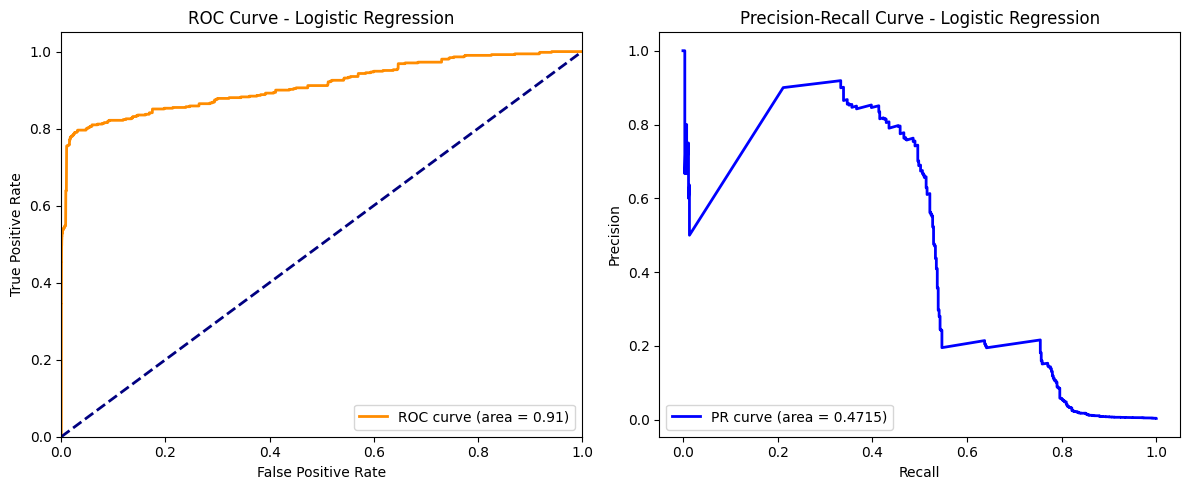

================ HistGradientBoosting (Limiar Padrão = 0.5) =================
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    138109
           1       0.18      0.90      0.31       510

    accuracy                           0.99    138619
   macro avg       0.59      0.94      0.65    138619
weighted avg       1.00      0.99      0.99    138619

================ HistGradientBoosting (Limiar Otimizado F1 = 0.9874) =================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    138109
           1       0.84      0.72      0.78       510

    accuracy                           1.00    138619
   macro avg       0.92      0.86      0.89    138619
weighted avg       1.00      1.00      1.00    138619



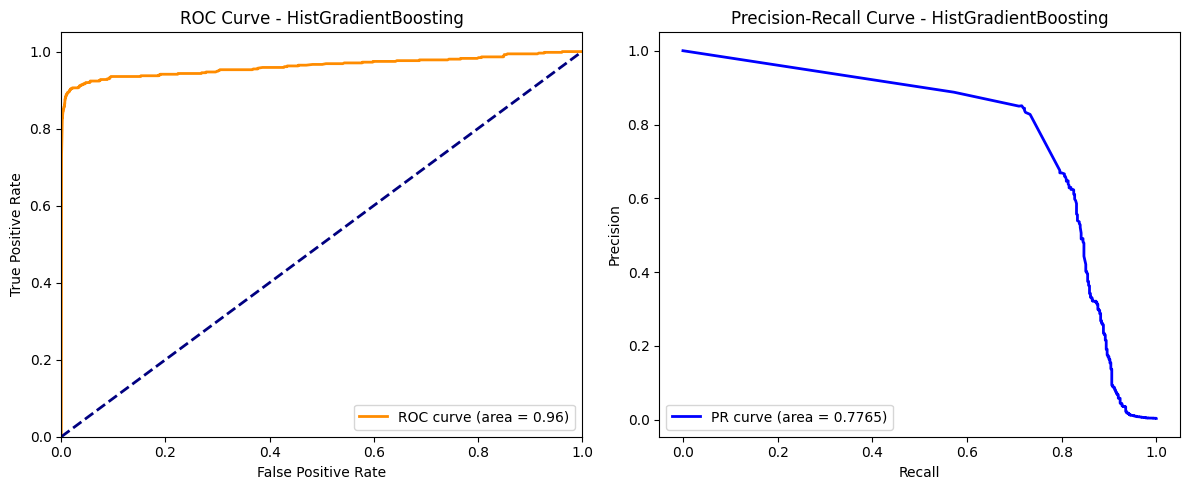

In [7]:
def plot_roc_pr(y_true, y_prob, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc="lower right")

    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {model_name}')
    plt.legend(loc="lower left")

    plt.tight_layout()
    plt.show()

# Busca do limiar ótimo que maximiza o F1-score para o HGB
precision_h, recall_h, thresholds_h = precision_recall_curve(y_test, y_prob_hgb)
f1_scores_h = 2 * (precision_h * recall_h) / (precision_h + recall_h + 1e-10)
best_idx = np.argmax(f1_scores_h)
best_threshold = thresholds_h[min(best_idx, len(thresholds_h)-1)]

# Predição usando o limiar ótimo vs limiar padrão
y_pred_hgb_opt = (y_prob_hgb >= best_threshold).astype(int)
y_pred_hgb_def = (y_prob_hgb >= 0.5).astype(int)

print("================ Regressão Logística =================")
print(classification_report(y_test, y_pred_lr))
plot_roc_pr(y_test, y_prob_lr, "Logistic Regression")

print("================ HistGradientBoosting (Limiar Padrão = 0.5) =================")
print(classification_report(y_test, y_pred_hgb_def))

print(f"================ HistGradientBoosting (Limiar Otimizado F1 = {best_threshold:.4f}) =================")
print(classification_report(y_test, y_pred_hgb_opt))
plot_roc_pr(y_test, y_prob_hgb, "HistGradientBoosting")

Calculando importância das features por permutação...


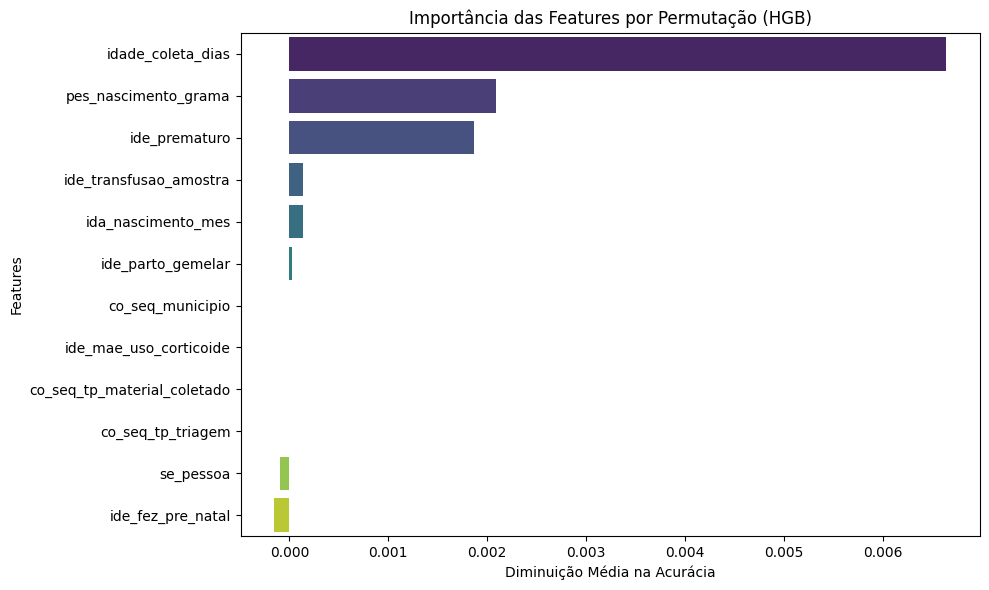

In [8]:
# Importância das features por permutação para o HistGradientBoosting
print("Calculando importância das features por permutação...")
result = permutation_importance(hgb, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
feature_importances = pd.DataFrame(
    result.importances_mean,
    index = X_test.columns,
    columns = ['importance']
).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances['importance'], y=feature_importances.index, palette='viridis')
plt.title('Importância das Features por Permutação (HGB)')
plt.xlabel('Diminuição Média na Acurácia')
plt.ylabel('Features')
plt.tight_layout()
plt.show()